## Introduction

Malaria is a life-threatening disease caused by parasites transmitted through the bites of infected female Anopheles mosquitoes. Early detection of malaria-infected cells plays a crucial role in preventing the disease from advancing and aiding faster treatment. In this project, the goal is to build a Convolutional Neural Network (CNN) model capable of distinguishing between parasitized and uninfected red blood cells based on microscopic images.
The dataset used for this project is publicly available and contains cell images labeled as either "Parasitized" or "Uninfected." The model is trained to identify subtle patterns and features that may not be easily noticeable to the human eye, allowing for fast and accurate classification. This approach aims to contribute to the automation of malaria detection processes in low-resource regions where expert diagnosis may not be readily available.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# The dataset was randomly split into training (80%) and validation (20%) using ImageDataGenerator.


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_path = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images"

img_size=224
batch_size=32

datagen= ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator= datagen.flow_from_directory(
    base_path,
    target_size=(img_size, img_size),
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

val_generator=datagen.flow_from_directory(
    base_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    shuffle=True,
    seed=42
)

2025-06-20 18:45:05.586952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750445106.047921      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750445106.193581      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


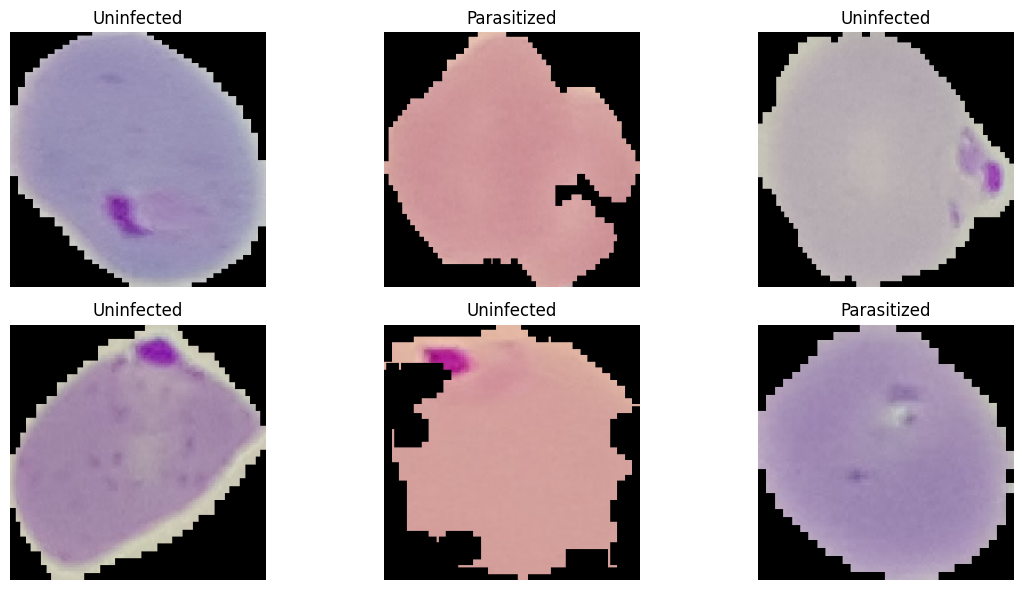

In [4]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title("Parasitized" if labels[i] == 1 else "Uninfected")
    plt.axis('off')
plt.tight_layout()
plt.show()


#from chatgpt

In [5]:
#A neural network model with convolutional layers was implemented to learn features from the input images and perform classification.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model=Sequential()
model.add(Conv2D(32, (3,3), activation="relu", input_shape=(img_size,img_size,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dropout(0.6))
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.6))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1750445153.742131      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750445153.743158      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      23,888,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history=model.fit(train_generator, epochs=5, validation_data=val_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1750445159.921141      79 service.cc:148] XLA service 0x7893ec00d4c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750445159.922979      79 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750445159.923011      79 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750445160.405288      79 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/689 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.5703 - loss: 2.4398   

I0000 00:00:1750445166.646219      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


689/689 ━━━━━━━━━━━━━━━━━━━━ 264s 369ms/step - accuracy: 0.5765 - loss: 0.9004 - val_accuracy: 0.6677 - val_loss: 0.6039
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 91s 131ms/step - accuracy: 0.7932 - loss: 0.4739 - val_accuracy: 0.8586 - val_loss: 0.3706
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 91s 133ms/step - accuracy: 0.9091 - loss: 0.2990 - val_accuracy: 0.9142 - val_loss: 0.2654
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 89s 129ms/step - accuracy: 0.9326 - loss: 0.2314 - val_accuracy: 0.9309 - val_loss: 0.2314
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 84s 122ms/step - accuracy: 0.9366 - loss: 0.1995 - val_accuracy: 0.9374 - val_loss: 0.2003


In [9]:
#saving model

model.save('/kaggle/working/malaria_cnn_model2.h5')


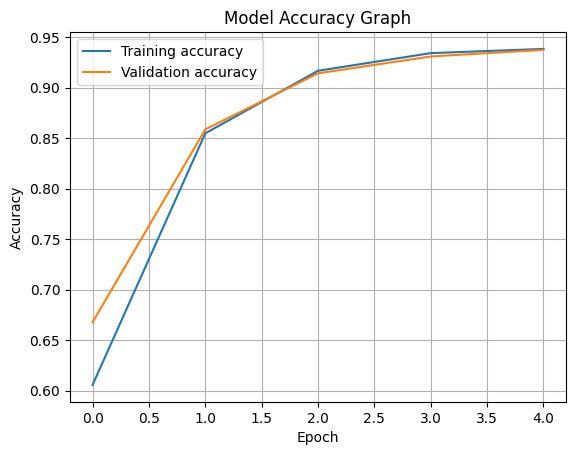

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Graph')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


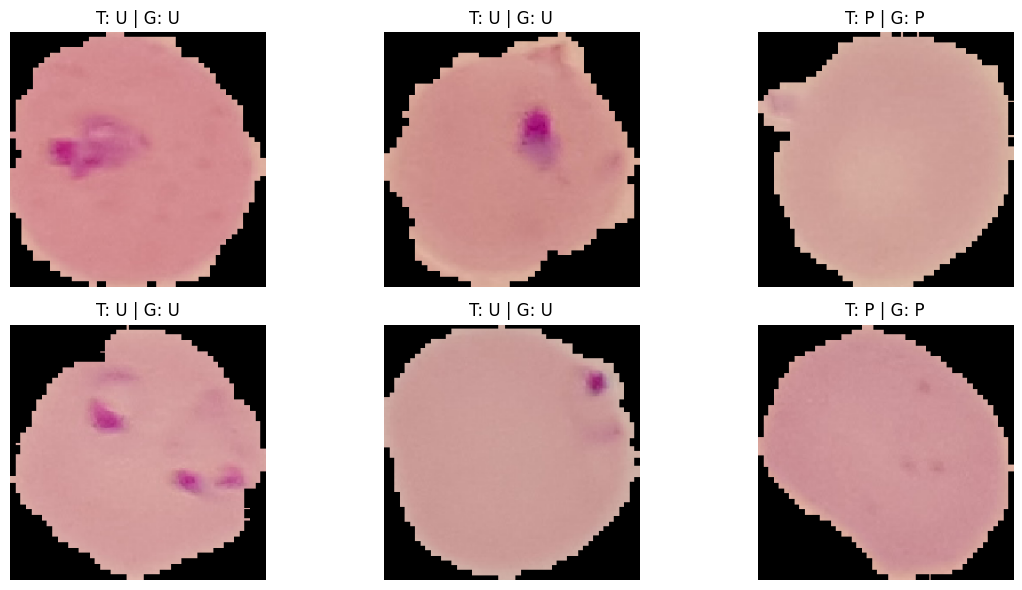

In [11]:
#testing

images, labels = next(val_generator)

fig, axs = plt.subplots(2, 3, figsize=(12, 6))
for ax, img, label in zip(axs.flat, images[:6], labels[:6]):
    pred = model.predict(img[np.newaxis, ...])[0][0]
    ax.imshow(img)
    ax.set_title(f"T: {'P' if pred>0.5 else 'U'} | G: {'P' if label==1 else 'U'}")
    ax.axis('off')
plt.tight_layout()
plt.show()


#from chatgpt

# Transfer Learning

VGG16 was imported with ImageNet weights and `include_top=False` to use its convolutional base for feature extraction. Custom dense layers were added on top for classification.


In [12]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.optimizers import Adam

base_model= VGG16(include_top=False, weights="imagenet", input_shape=(224,224,3))

#freezing
for layer in base_model.layers:
    layer.trainable= False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
model=Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.6))
model.add(Dense(1024, activation="relu"))
model.add(Dropout(0.6))
model.add(Dense(1,activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history=model.fit(train_generator, epochs=15,validation_data=val_generator)

Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 221s 293ms/step - accuracy: 0.7383 - loss: 0.8040 - val_accuracy: 0.8897 - val_loss: 0.2919
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 192s 279ms/step - accuracy: 0.8448 - loss: 0.3581 - val_accuracy: 0.8956 - val_loss: 0.2723
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 193s 280ms/step - accuracy: 0.8580 - loss: 0.3233 - val_accuracy: 0.8995 - val_loss: 0.2457
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 194s 281ms/step - accuracy: 0.8716 - loss: 0.3061 - val_accuracy: 0.9094 - val_loss: 0.2297
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 192s 279ms/step - accuracy: 0.8754 - loss: 0.2901 - val_accuracy: 0.9189 - val_loss: 0.2132
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 192s 279ms/step - accuracy: 0.8768 - loss: 0.2917 - val_accuracy: 0.9118 - val_loss: 0.2215
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 192s 278ms/step - accuracy: 0.8849 - loss: 0.2778 - val_accuracy: 0.9031 - val_loss: 0.2245
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 192s 279ms/step - accuracy: 0.8918 -

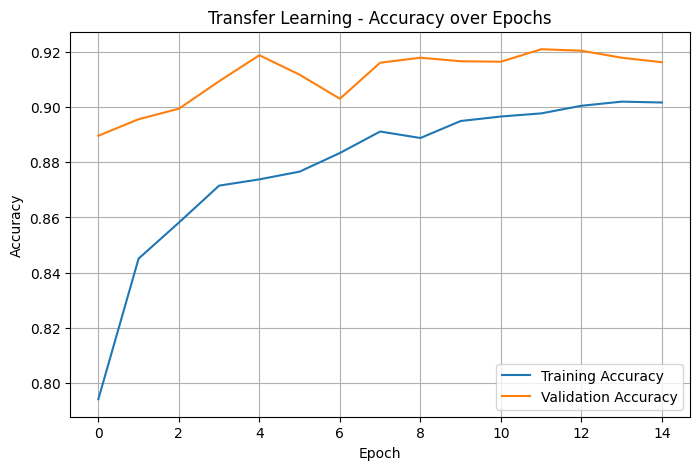

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning - Accuracy over Epochs")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

In this project, a CNN-based image classification model was successfully developed to detect malaria-infected cells from microscopic images. The model achieved high accuracy on both training and validation datasets, demonstrating its ability to generalize well and distinguish between parasitized and healthy cells effectively.
The results suggest that deep learning can serve as a powerful tool in medical image analysis, particularly for assisting in rapid malaria diagnosis. Further improvements could include the use of transfer learning with pre-trained models, testing on larger and more diverse datasets, and eventually deploying the model in real-world mobile or edge applications for field use.

  Resources
- Chatgpt
- Course education /old projects
